In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Nuevas librerías para la conexión a la base de datos y variables de entorno
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, exc

In [ ]:
# Carga de datos
# df_crypto = pd.read_csv("../data/clean/criptoradar_crypto_final_clean.csv")
try:
    # 1. Cargar las variables de entorno desde el archivo .env
    load_dotenv(dotenv_path="../.env") 
    
    db_user = os.getenv("DB_USER")
    db_pass = os.getenv("DB_PASS")
    db_host = os.getenv("DB_HOST")
    db_name = os.getenv("DB_NAME")
    
    # Validar que no falten variables en el archivo .env
    if not all([db_user, db_pass, db_host, db_name]):
        raise ValueError("Faltan una o más variables de entorno en el archivo .env")

    # 2. Crear el motor de conexión (engine) de SQLAlchemy
    connection_string = f"mysql+pymysql://{db_user}:{db_pass}@{db_host}/{db_name}"
    engine = create_engine(connection_string)
    
    # 3. Consulta SQL para traer el histórico de todas las criptomonedas
    query = """
    SELECT crypto_id, open, high, low, close, volume, datetime 
    FROM crypto_precios;
    """
    
    # 4. Cargar los datos directamente en el DataFrame que utiliza el notebook
    df_crypto = pd.read_sql(query, con=engine)
    print(f"¡Conexión exitosa! Se han cargado {len(df_crypto)} registros multidivisa desde la base de datos.")

except ValueError as ve:
    print(f"Error de Configuración: {ve}")
except exc.SQLAlchemyError as se:
    print(f"Error de Base de Datos: No se pudo conectar o extraer los precios cripto.\nDetalles: {se}")
except Exception as e:
    print(f"Error Inesperado: {e}")

¡Conexión exitosa! Se han cargado 6400 registros multidivisa desde la base de datos.


In [3]:
# INGENIERÍA DE FEATURES RAPIDA PARA EL ANÁLISIS
# Volatilidad porcentual relativa: (High - Low) / Open
df_crypto['daily_volatility_pct'] = (df_crypto['high'] - df_crypto['low']) / df_crypto['open'] * 100

### Relación de Volumen y Precio de cierre

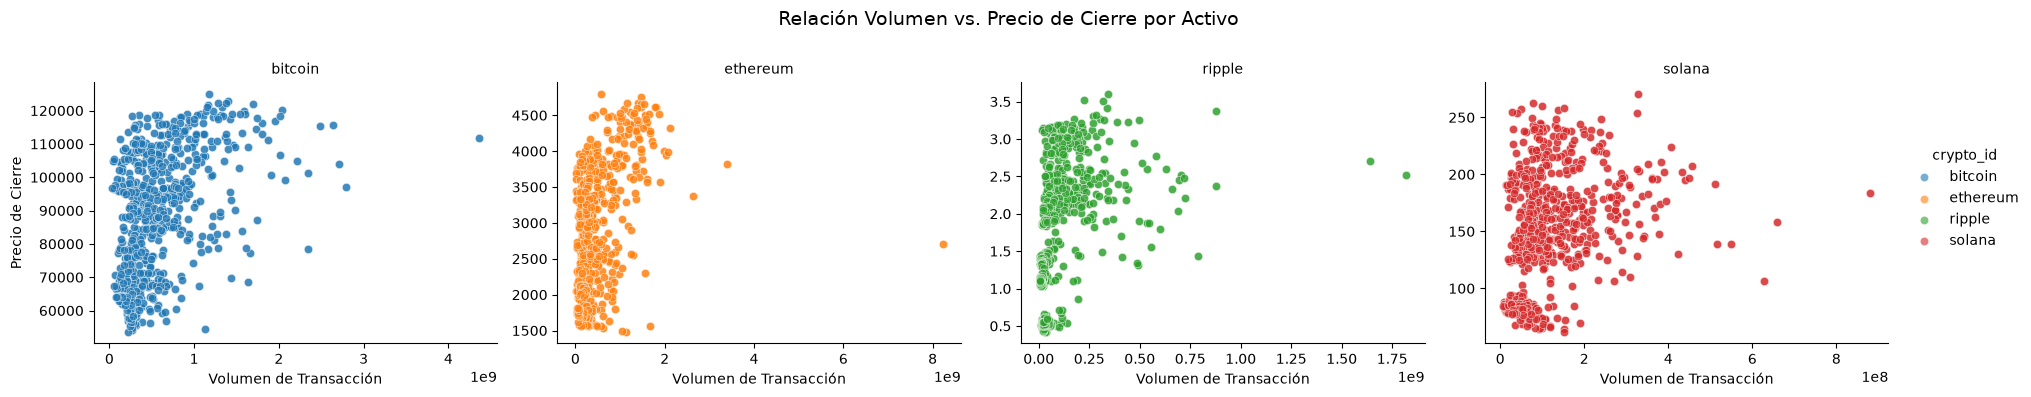

In [4]:
# 1. Numérica vs Numérica: Volumen vs. Cierre por Cripto
# =========================================================================
g = sns.FacetGrid(df_crypto, col="crypto_id", hue="crypto_id", sharey=False, sharex=False, height=4, aspect=1.2)
g.map(sns.scatterplot, "volume", "close", alpha=0.6)
g.add_legend()
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Volumen de Transacción", "Precio de Cierre")
plt.subplots_adjust(top=0.8)
g.fig.suptitle('Relación Volumen vs. Precio de Cierre por Activo', fontsize=14)
plt.show()

- Ausencia de correlación lineal clara: No se ve una línea diagonal perfecta en ninguno de los gráficos. Esto significa que un mayor volumen de transacciones no garantiza automáticamente un precio más alto (ni viceversa).

- Presencia de valores atípicos (Outliers): En casi todas las criptomonedas (especialmente en Ethereum y Ripple) existen días excepcionales donde el volumen explotó de forma masiva, pero el precio no sufrió un cambio drástico proporcional a ese volumen en ese instante.

- Concentración en "Zonas Comunes": El comportamiento habitual de estos activos es operar dentro de rangos de volumen estables y contenidos. Las anomalías de volumen alto son eventos raros o puntuales en el mercado.


### Compararativa de Volatilidad diaria entre Criptomonedas

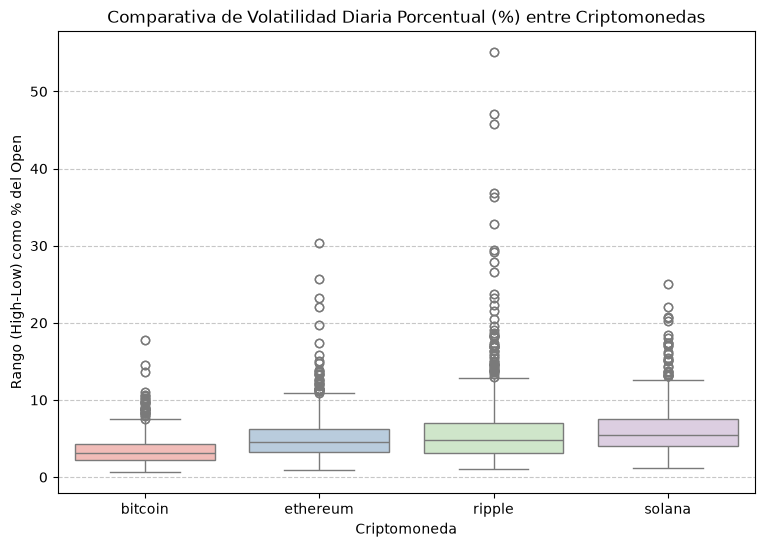

In [5]:
# 2. Categórica vs Numérica: Boxplot de Volatilidad Relativa
# =========================================================================
plt.figure(figsize=(9, 6))
sns.boxplot(data=df_crypto, x='crypto_id', y='daily_volatility_pct', palette='Pastel1',hue='crypto_id')
plt.title('Comparativa de Volatilidad Diaria Porcentual (%) entre Criptomonedas')
plt.xlabel('Criptomoneda')
plt.ylabel('Rango (High-Low) como % del Open')
plt.grid(axis='y', ls='--', alpha=0.7)
plt.show()

Este gráfico compara qué tan 'volátiles' o inestables son estas criptomonedas en su día a día. Nos muestra que Bitcoin es la más segura y predecible. En el extremo opuesto, Solana es la que muestra mayor movimiento en un día normal, mientras que Ripple es relativamente tranquila en el día a día pero es la más propensa a sufrir días de pánico o euforia extrema con picos de volatilidad que rozan el 55%.

- Bitcoin (Rosa): Es la más estable. Tiene la caja más baja y la línea de la mediana más cercana a cero (alrededor del 3%). Esto significa que en su día a día es la menos volátil. Incluso sus días atípicos son moderados, apenas superando el 15% de volatilidad.

- Ethereum (Azul): Volatilidad moderada. Su caja y su mediana están ligeramente más arriba que las de Bitcoin. Esto demuestra que tiende a ser un poco más nerviosa en el día a día, registrando algunos días atípicos que rozan el 30% de volatilidad.

- Ripple (Verde): El activo con los picos más extremos. Aunque su caja diaria (comportamiento normal) es similar a la de Ethereum o Solana, es la que tiene los valores atípicos más salvajes. Se observan días atípicos brutales donde la volatilidad superó el 45% y llegó hasta casi el 55% en un solo día. Es propensa a sufrir "shocks" o rachas de inestabilidad gigantescas.

- Solana (Morado): La volatilidad diaria más alta en promedio. Si te fijas en la línea del medio (mediana) y en la altura de su caja, es la que está situada más arriba de todas (su mediana ronda el 5.5%). Esto significa que, en un día cualquiera común y corriente, Solana tiende a fluctuar más que Bitcoin, Ethereum y Ripple, manteniendo una volatilidad constante más elevada, aunque sus días de picos máximos no sean tan altos como los de Ripple (se quedan bajo el 25%).



### Correlación Cruzada entre Criptomonedas

<Axes: xlabel='crypto_id', ylabel='crypto_id'>

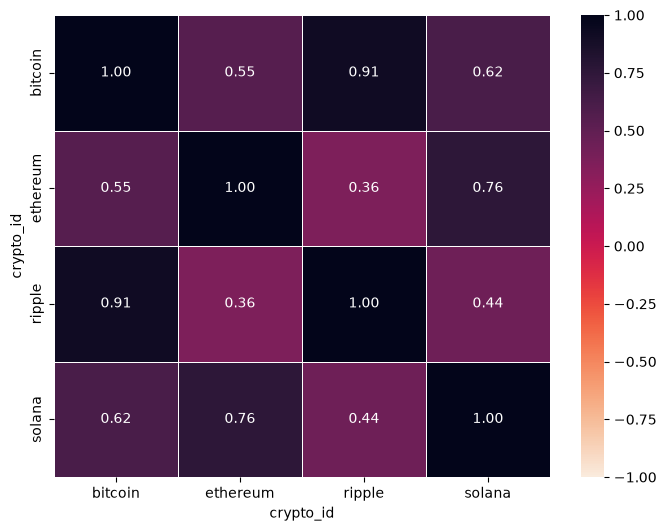

In [6]:
# 3. Correlación Cruzada entre Precios (Pivot Table)
# =========================================================================

# ELIMINAMOS REGISTROS DUPLICADOS (dejando solo el primero que encuentre por cada cripto y fecha)
df_crypto_clean = df_crypto.drop_duplicates(subset=['datetime', 'crypto_id'], keep='first')

# Ahora sí pivotamos de forma segura usando el DataFrame limpio
df_pivot = df_crypto_clean.pivot(index='datetime', columns='crypto_id', values='close').dropna()

plt.figure(figsize=(8, 6))
sns.heatmap(df_pivot.corr(method='pearson'), annot=True, cmap='rocket_r', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

- La pareja más fuerte (Bitcoin y Ripple = 0.91): Tienen una correlación extremadamente alta (0.92). Esto nos indica que sus precios se mueven prácticamente al unísono. Si Bitcoin experimenta una tendencia alcista o bajista, hay una probabilidad altísima de que Ripple replique ese mismo movimiento exacto.

- La conexión moderna (Ethereum y Solana = 0.76), muestran una correlación sólida y fuerte (0.76). Es un comportamiento lógico en el mercado, ya que ambas son las principales redes de contratos inteligentes y ecosistemas de aplicaciones descentralizadas, por lo que suelen reaccionar de forma similar a las tendencias tecnológicas.

- Los movimientos más independientes (Ethereum y Ripple = 0.36): Es la correlación más baja de toda la matriz (0.36). Aunque sigue siendo positiva (no se mueven al revés), es una relación débil. Esto significa que lo que le pase al precio de Ethereum influye muy poco en el comportamiento de Ripple, y viceversa.